# 🌊 Bangalore Lakes Water Quality — Complete ML Pipeline

**Dataset:** Master dataset of Bangalore lake water quality monitoring (Jul 2023 – Nov 2025)  
**File:** `master_dataset.csv` (located in the same `Analysis/` folder)

## Pipeline Overview
| Stage | Description |
|-------|-------------|
| 1 | Data Loading & EDA |
| 2 | Cleaning, Preprocessing & Outlier Detection (IQR capping) |
| 3 | Feature Engineering (temporal, categorical encoding) |
| 4 | **12 Classical ML Models** for 5 targets |
| 5 | **GridSearchCV** Hyperparameter Tuning |
| 6 | **Neural Nets**: FNN, 1D-CNN, LSTM |
| 7 | Comparison Tables & Visualisations |
| 8 | Export Predictions |

**Target Factors:** `DO`, `BOD`, `PH`, `COD`, `NITRATE_N`

---
## 0. Install & Import Dependencies

In [85]:
# Uncomment to install missing packages
# !pip install scikit-learn xgboost lightgbm tensorflow pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# ── Optional boosting libs ────────────────────────────────────────────────────
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False; print('xgboost not found')

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False; print('lightgbm not found')

# ── TensorFlow ────────────────────────────────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
    print(f'TensorFlow {tf.__version__}')
except ImportError:
    HAS_TF = False; print('TensorFlow not found — neural net section skipped')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ Imports complete')

TensorFlow 2.20.0
✅ Imports complete


---
## 1. Data Loading & Exploratory Data Analysis

In [86]:
DATA_PATH = Path('master_dataset.csv')
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (2924, 34)


,MONTH_YEAR,STN_CODE,NAMEOFMONITORINGLOCATION,USEBASEDCLASS,DO,PH,CONDUCTIVITY,BOD,NITRATE_N,FECAL_COLI,...,TOTALDISSOLVEDSOLIDS,TOTALSUSPENDEDSOLIDS,PHOSPHATE,BORON,POTASSIUM,FLUORIDE,SODIUMPERCENTAGE,SAR,ORTHOPHOSPHATE,YEAR
0,07/23,5574.0,DEVASANDRA LAKE,"D (Propagation of wild life,fisheries)",4.4,8.2,392.0,7.0,1.0,6300.0,...,268.0,12.175824,0.56,0.5,13.0,0.23,43.956044,1.794505,0.297253,2023.0
1,07/23,5574.0,HEBBAL LAKE,"D (Propagation of wild life,fisheries)",4.7,7.2,550.0,8.0,2.0,2300.0,...,376.0,12.351648,0.98,0.5,27.0,0.28,43.912088,1.789011,0.294505,2023.0
2,07/23,5574.0,JAKKUR LAKE,"E (Irrigation, industrial cooling and controll...",2.6,7.0,908.0,12.0,4.1,4000.0,...,620.0,12.527473,2.40,0.5,32.0,0.45,43.868132,1.783516,0.291758,2023.0


In [87]:
# Null counts
info = pd.DataFrame({'dtype': df_raw.dtypes,
                     'nulls': df_raw.isnull().sum(),
                     'null_pct': (df_raw.isnull().mean()*100).round(2)})
print(info.to_string())

                             dtype  nulls  null_pct
MONTH_YEAR                     str      0       0.0
STN_CODE                   float64      0       0.0
NAMEOFMONITORINGLOCATION       str      0       0.0
USEBASEDCLASS                  str      0       0.0
DO                         float64      0       0.0
PH                         float64      0       0.0
CONDUCTIVITY               float64      0       0.0
BOD                        float64      0       0.0
NITRATE_N                  float64      0       0.0
FECAL_COLI                 float64      0       0.0
TOTAL_COLI                 float64      0       0.0
CARBONATE                  float64      0       0.0
BICARBONATE                float64      0       0.0
PHENOLPHTHALEINALKALINITY  float64      0       0.0
TOTALALKALINITY            float64      0       0.0
CHLORIDES                  float64      0       0.0
COD                        float64      0       0.0
TOTALKJELDAHLNITROGEN      float64      0       0.0
AMMONICALN  

In [88]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
STN_CODE,2924.0,4.176440e+03,1.165237e+03,6.30,3615.000000,4506.000000,4540.000000,5.844000e+03
DO,2924.0,4.089538e+00,1.956669e+00,0.02,2.800000,4.600000,5.700000,8.000000e+00
PH,2924.0,8.162867e+02,2.654938e+04,1.90,7.000000,7.400000,7.900000,1.100000e+06
CONDUCTIVITY,2924.0,4.817319e+03,1.245847e+05,63.00,512.000000,740.000000,1140.000000,4.900000e+06
BOD,2924.0,1.481648e+01,2.021884e+01,3.20,5.000000,8.000000,17.000000,4.500000e+02
NITRATE_N,2924.0,3.379207e+00,2.900932e+00,0.30,1.870000,2.800000,4.000000,4.900000e+01
FECAL_COLI,2924.0,4.455898e+05,2.038215e+07,2.00,230.000000,630.000000,2600.000000,1.100000e+09
TOTAL_COLI,2924.0,1.579365e+06,6.171097e+07,1.50,2400.000000,5400.000000,16000.000000,3.300000e+09
CARBONATE,2924.0,1.899248e+01,4.262540e+01,3.00,3.000000,3.000000,18.862857,4.360000e+02
BICARBONATE,2924.0,1.940414e+02,1.407183e+02,8.00,112.000000,156.000000,240.000000,2.590000e+03


In [89]:
print('Month-Year entries:', sorted(df_raw['MONTH_YEAR'].dropna().unique()))

Month-Year entries: ['01/25', '02/25', '03/24', '03/25', '04/24', '04/25', '05/24', '05/25', '06/24', '06/25', '07/23', '07/24', '07/25', '08/23', '08/24', '08/25', '09/23', '09/24', '09/25', '10/23', '10/24', '10/25', '11/25', '12/23', '12/24']


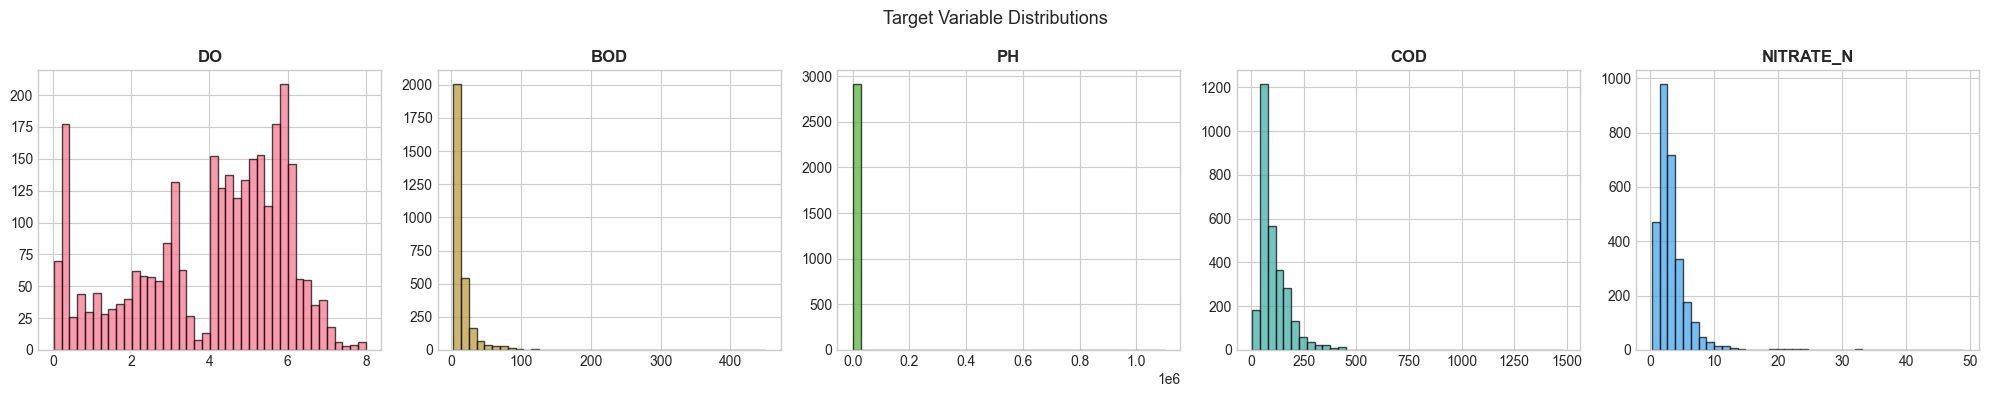

In [90]:
# Target variable distributions
TARGETS = ['DO', 'BOD', 'PH', 'COD', 'NITRATE_N']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, TARGETS):
    ax.hist(df_raw[col].dropna(), bins=40, edgecolor='k', alpha=0.7, color=f'C{TARGETS.index(col)}')
    ax.set_title(col, fontweight='bold')
plt.suptitle('Target Variable Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

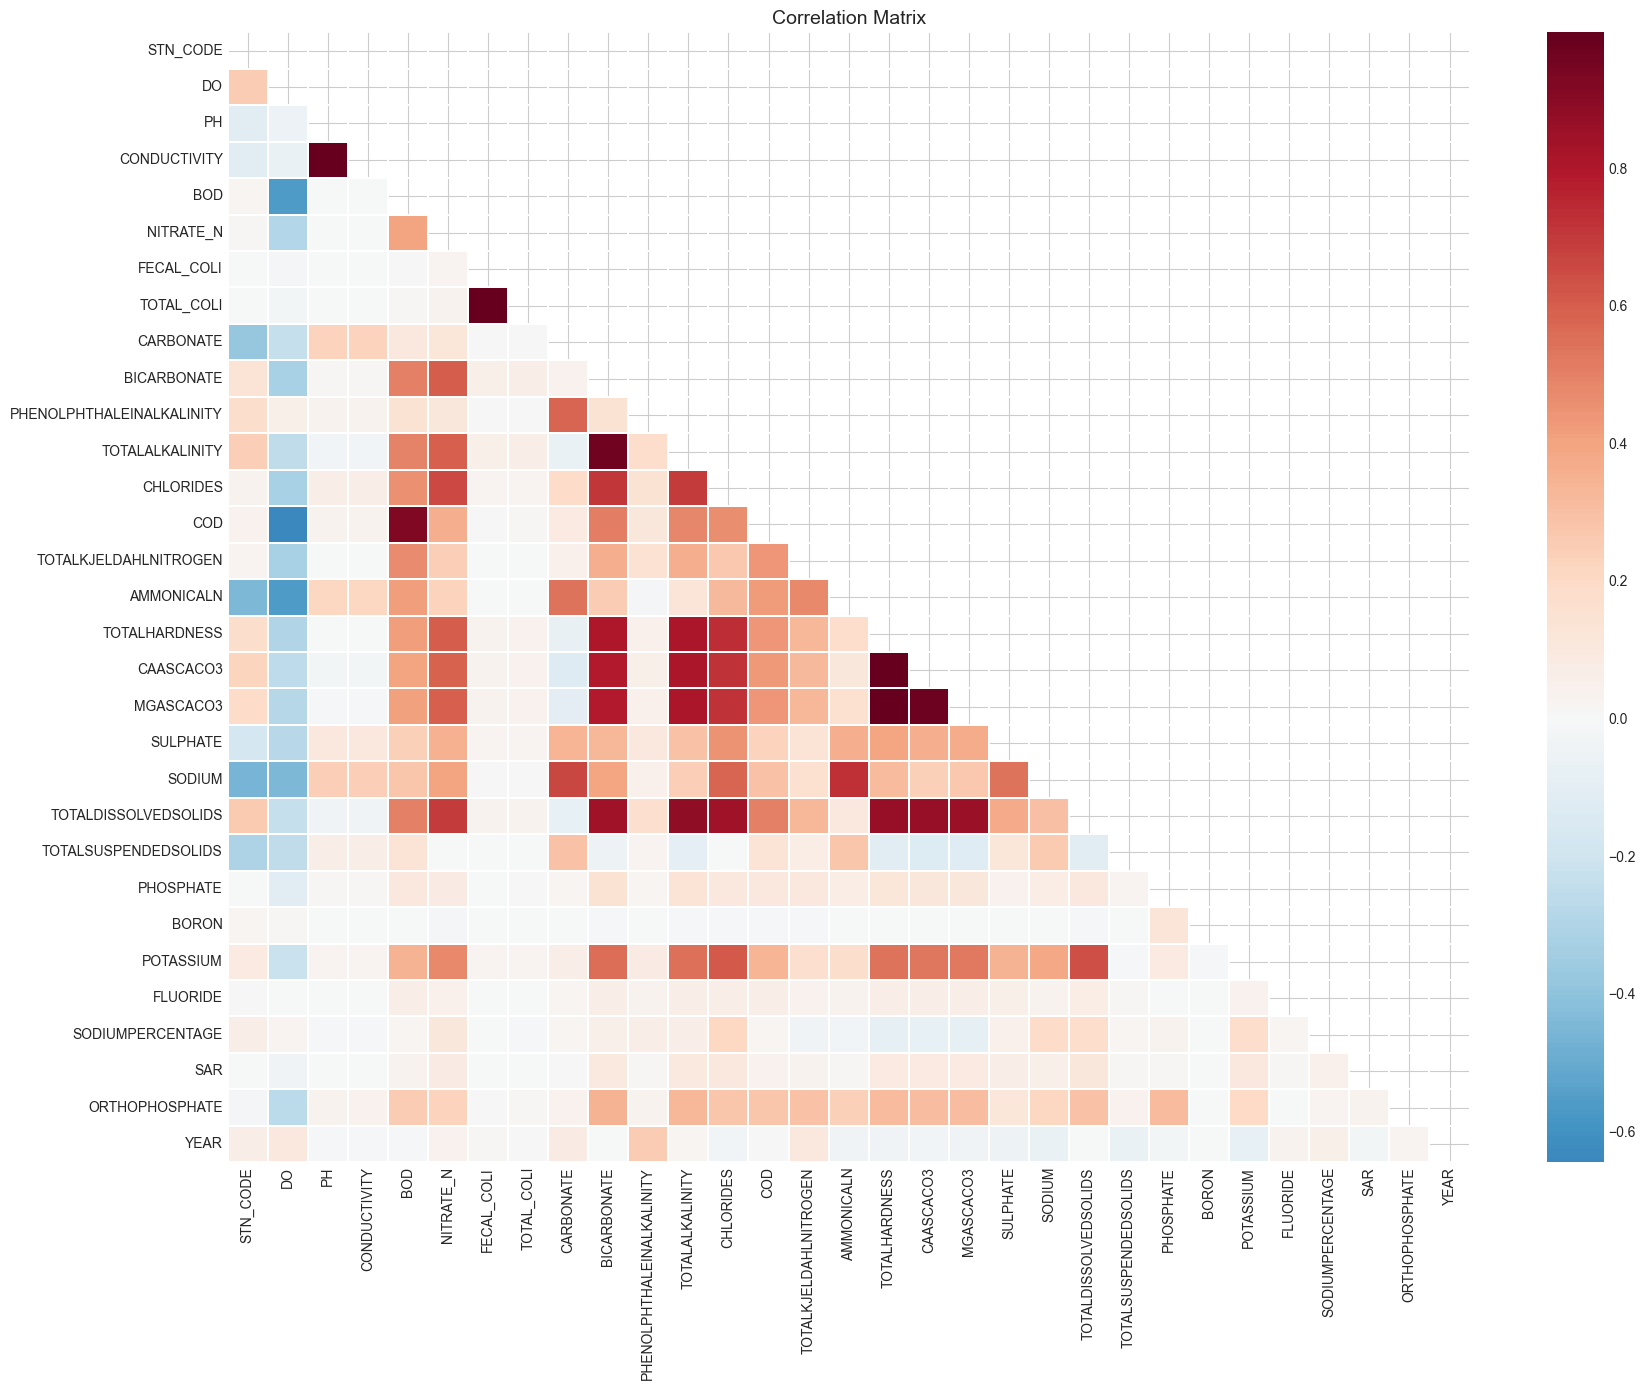

In [91]:
# Correlation heatmap
num_cols = df_raw.select_dtypes(include=np.number).columns
corr = df_raw[num_cols].corr()
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.3, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Data Cleaning & Preprocessing

In [92]:
df = df_raw.copy()

# 2.1 Parse MONTH_YEAR
def parse_month_year(s):
    try:
        p = str(s).strip().split('/')
        if len(p) == 2:
            m, y = int(p[0]), int(p[1])
            if y < 100: y += 2000
            return m, y
    except Exception:
        pass
    return np.nan, np.nan

df[['MONTH', 'YEAR_PARSED']] = df['MONTH_YEAR'].apply(
    lambda x: pd.Series(parse_month_year(x))
)
df['TIME_IDX'] = (df['YEAR_PARSED'] - 2023) * 12 + df['MONTH']

# 2.2 Encode USEBASEDCLASS
def encode_useclass(s):
    s = str(s).upper()
    if 'D (' in s: return 0   # Class D – wildlife/fisheries
    elif 'E (' in s: return 1  # Class E – irrigation/industry
    else: return 2

df['USECLASS_ENC'] = df['USEBASEDCLASS'].apply(encode_useclass)
print('USECLASS_ENC distribution:')
print(df['USECLASS_ENC'].value_counts())

USECLASS_ENC distribution:
USECLASS_ENC
0    1198
2    1055
1     671
Name: count, dtype: int64


In [93]:
# 2.3 Feature columns
FEATURE_COLS = [
    'MONTH', 'TIME_IDX', 'USECLASS_ENC',
    'CONDUCTIVITY', 'FECAL_COLI', 'TOTAL_COLI',
    'CARBONATE', 'BICARBONATE', 'PHENOLPHTHALEINALKALINITY', 'TOTALALKALINITY',
    'CHLORIDES', 'TOTALKJELDAHLNITROGEN', 'AMMONICALN',
    'TOTALHARDNESS', 'CAASCACO3', 'MGASCACO3', 'SULPHATE',
    'SODIUM', 'TOTALDISSOLVEDSOLIDS', 'TOTALSUSPENDEDSOLIDS',
    'PHOSPHATE', 'BORON', 'POTASSIUM', 'FLUORIDE',
    'SODIUMPERCENTAGE', 'SAR', 'ORTHOPHOSPHATE'
]
print(f'Features: {len(FEATURE_COLS)}, Targets: {TARGETS}')

Features: 27, Targets: ['DO', 'BOD', 'PH', 'COD', 'NITRATE_N']


In [94]:
# 2.4 Outlier capping (IQR × 3)
def cap_outliers_iqr(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(lower=q1 - factor*iqr, upper=q3 + factor*iqr)

df_clean = df.copy()
for col in FEATURE_COLS + TARGETS:
    if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = cap_outliers_iqr(df_clean[col])
print('✅ Outlier capping done')

✅ Outlier capping done


In [95]:
# 2.5 Median imputation
all_cols = [c for c in FEATURE_COLS + TARGETS if c in df_clean.columns]
imp = SimpleImputer(strategy='median')
df_clean[all_cols] = imp.fit_transform(df_clean[all_cols])
print(f'NaNs after imputation: {df_clean[all_cols].isnull().sum().sum()}')
print(f'Dataset shape: {df_clean.shape}')

NaNs after imputation: 0
Dataset shape: (2924, 38)


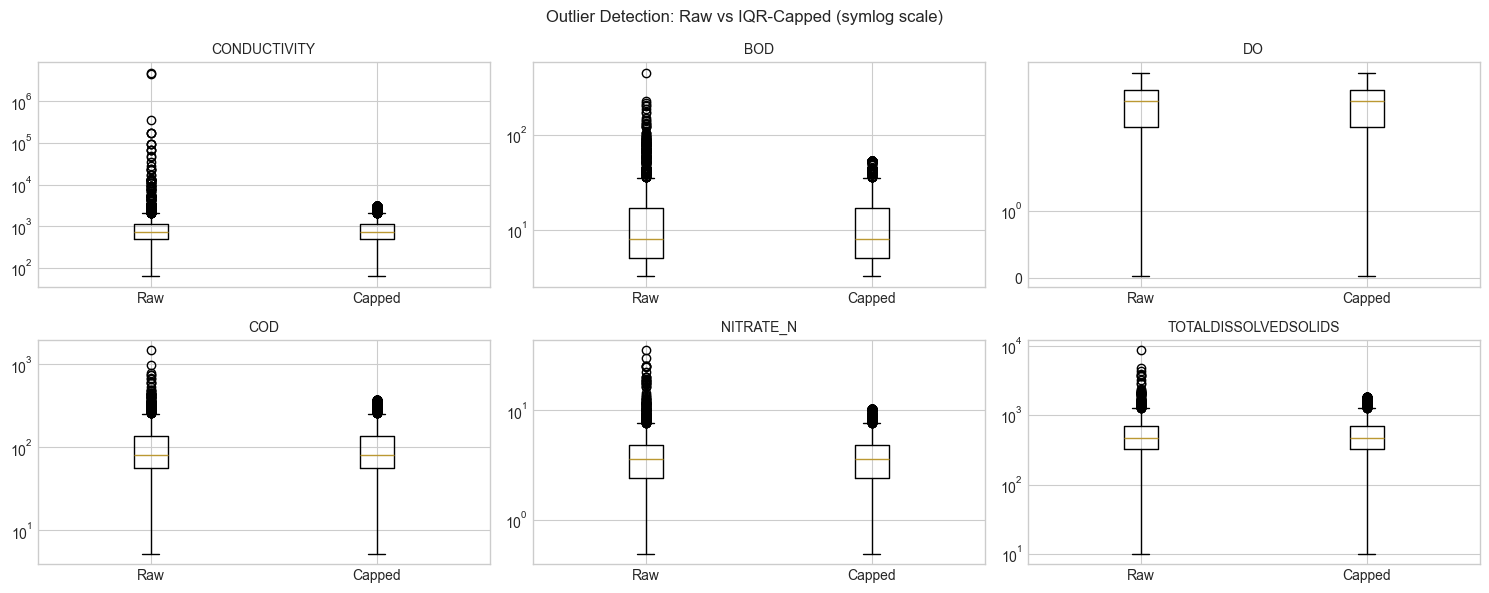

In [96]:
# 2.6 Boxplots — raw vs capped
key_features = ['CONDUCTIVITY', 'BOD', 'DO', 'COD', 'NITRATE_N', 'TOTALDISSOLVEDSOLIDS']
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()
for i, col in enumerate(key_features):
    if col in df_raw.columns:
        axes[i].boxplot([df_raw[col].dropna(), df_clean[col].dropna()],
                        labels=['Raw', 'Capped'])
        axes[i].set_title(col, fontsize=10)
        axes[i].set_yscale('symlog')
plt.suptitle('Outlier Detection: Raw vs IQR-Capped (symlog scale)', fontsize=12)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Model Utilities

In [97]:
def compute_metrics(y_true, y_pred, name='model'):
    return {
        'Model': name,
        'RMSE':  round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'MAE':   round(mean_absolute_error(y_true, y_pred), 4),
        'R2':    round(r2_score(y_true, y_pred), 4)
    }

def get_classical_models():
    models = {
        'LinearRegression':  LinearRegression(),
        'Ridge':             Ridge(alpha=1.0),
        'Lasso':             Lasso(alpha=0.1, max_iter=5000),
        'ElasticNet':        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
        'DecisionTree':      DecisionTreeRegressor(random_state=42),
        'RandomForest':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'ExtraTrees':        ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'GradientBoosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
        'AdaBoost':          AdaBoostRegressor(n_estimators=100, random_state=42),
        'SVR':               SVR(kernel='rbf', C=10, epsilon=0.1),
        'KNN':               KNeighborsRegressor(n_neighbors=5),
    }
    if HAS_XGB:
        models['XGBoost']  = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
    if HAS_LGB:
        models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
    return models

SCALE_MODELS = ('LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'SVR', 'KNN')

def train_evaluate_all(X_train, X_test, y_train, y_test):
    models = get_classical_models()
    scaler = StandardScaler()
    Xtr_sc = scaler.fit_transform(X_train)
    Xte_sc = scaler.transform(X_test)
    results = []
    for name, model in models.items():
        Xtr, Xte = (Xtr_sc, Xte_sc) if name in SCALE_MODELS else (X_train, X_test)
        try:
            model.fit(Xtr, y_train)
            results.append(compute_metrics(y_test, model.predict(Xte), name))
            print(f'  ✓ {name}')
        except Exception as e:
            print(f'  ✗ {name}: {e}')
    df_res = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
    return df_res, models, scaler

print('✅ Utilities defined')

✅ Utilities defined


---
## 4. Classical ML — 12 Models × 5 Targets

In [98]:
feat_avail = [c for c in FEATURE_COLS if c in df_clean.columns]
X = df_clean[feat_avail].values

all_results = {}   # target -> results DataFrame
best_models = {}   # target -> (name, fitted_model, scaler)

for target in TARGETS:
    if target not in df_clean.columns:
        print(f'⚠️  {target} missing, skipping'); continue

    y    = df_clean[target].values
    mask = ~np.isnan(y)
    Xm, ym = X[mask], y[mask]

    X_tr, X_te, y_tr, y_te = train_test_split(Xm, ym, test_size=0.2, random_state=42)
    print(f'\n{"="*55}\n  TARGET: {target}  Train={len(X_tr)} Test={len(X_te)}\n{"="*55}')

    df_res, models, scaler = train_evaluate_all(X_tr, X_te, y_tr, y_te)
    all_results[target] = df_res

    best_name = df_res.iloc[0]['Model']
    best_models[target] = (best_name, models[best_name], scaler)
    print(f'  → Best: {best_name}  R²={df_res.iloc[0]["R2"]}')

print('\n✅ Classical ML complete')


  TARGET: DO  Train=2339 Test=585
  ✓ LinearRegression
  ✓ Ridge
  ✓ Lasso
  ✓ ElasticNet
  ✓ DecisionTree
  ✓ RandomForest
  ✓ ExtraTrees
  ✓ GradientBoosting
  ✓ AdaBoost
  ✓ SVR
  ✓ KNN
  ✓ XGBoost
  ✓ LightGBM
  → Best: LightGBM  R²=0.8367

  TARGET: BOD  Train=2339 Test=585
  ✓ LinearRegression
  ✓ Ridge
  ✓ Lasso
  ✓ ElasticNet
  ✓ DecisionTree
  ✓ RandomForest
  ✓ ExtraTrees
  ✓ GradientBoosting
  ✓ AdaBoost
  ✓ SVR
  ✓ KNN
  ✓ XGBoost
  ✓ LightGBM
  → Best: ExtraTrees  R²=0.7411

  TARGET: PH  Train=2339 Test=585
  ✓ LinearRegression
  ✓ Ridge
  ✓ Lasso
  ✓ ElasticNet
  ✓ DecisionTree
  ✓ RandomForest
  ✓ ExtraTrees
  ✓ GradientBoosting
  ✓ AdaBoost
  ✓ SVR
  ✓ KNN
  ✓ XGBoost
  ✓ LightGBM
  → Best: RandomForest  R²=0.7109

  TARGET: COD  Train=2339 Test=585
  ✓ LinearRegression
  ✓ Ridge
  ✓ Lasso
  ✓ ElasticNet
  ✓ DecisionTree
  ✓ RandomForest
  ✓ ExtraTrees
  ✓ GradientBoosting
  ✓ AdaBoost
  ✓ SVR
  ✓ KNN
  ✓ XGBoost
  ✓ LightGBM
  → Best: ExtraTrees  R²=0.7592

  TARGET:

In [99]:
# Summary tables
for target, res_df in all_results.items():
    print(f'\n── {target} ──')
    display(res_df
                  )


── DO ──


,Model,RMSE,MAE,R2
0,LightGBM,0.8002,0.6058,0.8367
1,ExtraTrees,0.8046,0.5989,0.8348
2,RandomForest,0.8095,0.6066,0.8328
3,XGBoost,0.8436,0.6519,0.8184
4,GradientBoosting,0.8580,0.6497,0.8122
5,SVR,0.9507,0.7333,0.7694
6,Ridge,1.0531,0.8116,0.7171
7,LinearRegression,1.0545,0.8121,0.7163
8,ElasticNet,1.0760,0.8355,0.7046
9,AdaBoost,1.0833,0.8960,0.7006



── BOD ──


,Model,RMSE,MAE,R2
0,ExtraTrees,6.3640,3.6321,0.7411
1,GradientBoosting,6.5778,3.9685,0.7234
2,RandomForest,6.5851,3.7992,0.7228
3,LightGBM,6.7206,3.9116,0.7113
4,XGBoost,6.8692,3.8948,0.6984
5,LinearRegression,7.2768,4.8604,0.6615
6,Ridge,7.2784,4.8619,0.6614
7,Lasso,7.3717,4.8823,0.6526
8,ElasticNet,7.3900,4.9416,0.6509
9,SVR,7.6262,4.2947,0.6282



── PH ──


,Model,RMSE,MAE,R2
0,RandomForest,0.4513,0.3454,0.7109
1,ExtraTrees,0.4580,0.3342,0.7023
2,LightGBM,0.4603,0.3538,0.6993
3,GradientBoosting,0.4737,0.3757,0.6815
4,XGBoost,0.4847,0.3691,0.6665
5,SVR,0.5008,0.3840,0.6440
6,AdaBoost,0.5217,0.4398,0.6137
7,KNN,0.5223,0.3998,0.6128
8,LinearRegression,0.5329,0.4313,0.5970
9,Ridge,0.5330,0.4316,0.5968



── COD ──


,Model,RMSE,MAE,R2
0,ExtraTrees,34.4108,21.5702,0.7592
1,GradientBoosting,36.0618,23.8770,0.7356
2,LightGBM,36.2463,23.5358,0.7328
3,RandomForest,36.8094,23.1184,0.7245
4,XGBoost,37.9722,23.9658,0.7068
5,Ridge,41.9011,29.5668,0.6430
6,LinearRegression,41.9196,29.5858,0.6427
7,Lasso,42.0978,29.7534,0.6396
8,ElasticNet,42.5063,30.1684,0.6326
9,KNN,46.1261,30.5542,0.5673



── NITRATE_N ──


,Model,RMSE,MAE,R2
0,LightGBM,0.9289,0.5032,0.7921
1,ExtraTrees,0.9294,0.4334,0.7918
2,GradientBoosting,0.9641,0.4758,0.7760
3,RandomForest,0.9649,0.4559,0.7756
4,XGBoost,1.0017,0.5147,0.7582
5,SVR,1.0303,0.4401,0.7442
6,KNN,1.0645,0.6361,0.7269
7,LinearRegression,1.0667,0.5212,0.7258
8,Ridge,1.0667,0.5211,0.7258
9,ElasticNet,1.0811,0.5330,0.7184


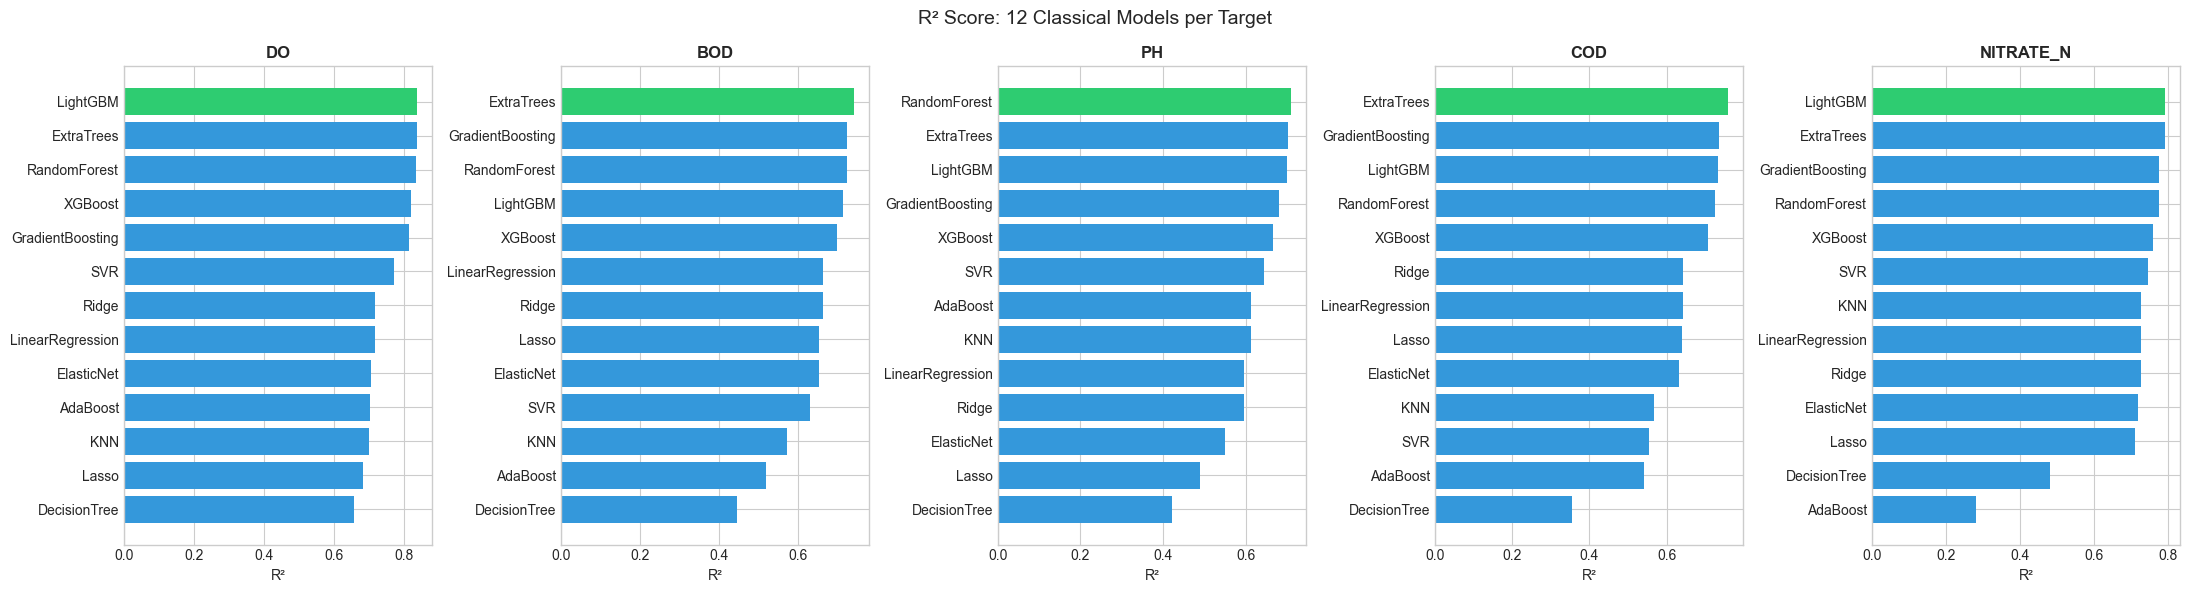

In [100]:
# R² bar charts
fig, axes = plt.subplots(1, len(TARGETS), figsize=(22, 6), sharey=False)
for ax, target in zip(axes, TARGETS):
    if target not in all_results: continue
    df_r = all_results[target]
    colors = ['#2ecc71' if r == df_r['R2'].max() else '#3498db' for r in df_r['R2']]
    ax.barh(df_r['Model'], df_r['R2'], color=colors)
    ax.set_title(target, fontweight='bold')
    ax.set_xlabel('R²'); ax.axvline(0, color='k', lw=0.5)
    ax.invert_yaxis()
plt.suptitle('R² Score: 12 Classical Models per Target', fontsize=14)
plt.tight_layout()
plt.savefig('classical_model_r2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Hyperparameter Tuning — GridSearchCV

In [101]:
PARAM_GRIDS = {
    'RandomForest':     {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
                          'min_samples_split': [2, 5]},
    'GradientBoosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1],
                          'max_depth': [3, 5]},
    'ExtraTrees':       {'n_estimators': [100, 200], 'max_depth': [None, 10],
                          'min_samples_split': [2, 5]},
    'Ridge':            {'alpha': [0.1, 1.0, 10.0, 100.0]},
    'SVR':              {'C': [1, 10, 100], 'epsilon': [0.01, 0.1, 0.5]},
}
if HAS_XGB:
    PARAM_GRIDS['XGBoost'] = {'n_estimators': [100, 200],
                               'learning_rate': [0.05, 0.1], 'max_depth': [4, 6]}
if HAS_LGB:
    PARAM_GRIDS['LightGBM'] = {'n_estimators': [100, 200],
                                'learning_rate': [0.05, 0.1], 'num_leaves': [31, 63]}

MODEL_CONSTRUCTORS = {
    'RandomForest':     lambda: RandomForestRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': lambda: GradientBoostingRegressor(random_state=42),
    'ExtraTrees':       lambda: ExtraTreesRegressor(random_state=42, n_jobs=-1),
    'Ridge':            lambda: Ridge(),
    'SVR':              lambda: SVR(kernel='rbf'),
}
if HAS_XGB:
    MODEL_CONSTRUCTORS['XGBoost']  = lambda: xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
if HAS_LGB:
    MODEL_CONSTRUCTORS['LightGBM'] = lambda: lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1)

tuned_results = {}

for target in TARGETS:
    if target not in df_clean.columns or target not in all_results: continue

    y    = df_clean[target].values
    mask = ~np.isnan(y)
    Xm, ym = X[mask], y[mask]
    X_tr, X_te, y_tr, y_te = train_test_split(Xm, ym, test_size=0.2, random_state=42)

    # Pick model to tune
    candidate = all_results[target].iloc[0]['Model']
    tune_name = candidate if candidate in PARAM_GRIDS else 'RandomForest'
    print(f'\n[{target}] Tuning {tune_name} ...')

    sc = StandardScaler()
    if tune_name in SCALE_MODELS:
        Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    else:
        Xtr, Xte = X_tr, X_te

    grid = GridSearchCV(MODEL_CONSTRUCTORS[tune_name](), PARAM_GRIDS[tune_name],
                        cv=5, scoring='r2', n_jobs=-1, verbose=0)
    grid.fit(Xtr, y_tr)
    m = compute_metrics(y_te, grid.best_estimator_.predict(Xte), f'{tune_name}_Tuned')

    tuned_results[target] = {
        'model_name': tune_name,
        'best_params': grid.best_params_,
        'cv_r2': round(grid.best_score_, 4),
        'metrics': m,
        'estimator': grid.best_estimator_,
        'scaler': sc
    }
    print(f'  Params: {grid.best_params_}')
    print(f'  CV R²={grid.best_score_:.4f}  Test R²={m["R2"]}')

print('\n✅ GridSearchCV done')


[DO] Tuning LightGBM ...
  Params: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}
  CV R²=0.7879  Test R²=0.8322

[BOD] Tuning ExtraTrees ...
  Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  CV R²=0.7066  Test R²=0.7482

[PH] Tuning RandomForest ...
  Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
  CV R²=0.7006  Test R²=0.7109

[COD] Tuning ExtraTrees ...
  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  CV R²=0.7105  Test R²=0.7577

[NITRATE_N] Tuning LightGBM ...
  Params: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}
  CV R²=0.7297  Test R²=0.7946

✅ GridSearchCV done


In [102]:
# Classical vs Tuned comparison
rows = []
for t in TARGETS:
    if t not in all_results or t not in tuned_results: continue
    bc = all_results[t].iloc[0]
    tr = tuned_results[t]
    rows.append({'Target': t,
                 'Best Classical': bc['Model'], 'Classical R2': bc['R2'], 'Classical RMSE': bc['RMSE'],
                 'Tuned Model': tr['model_name'], 'Tuned R2': tr['metrics']['R2'],
                 'Tuned RMSE': tr['metrics']['RMSE']})
df_cmp = pd.DataFrame(rows)
display(df_cmp)

,Target,Best Classical,Classical R2,Classical RMSE,Tuned Model,Tuned R2,Tuned RMSE
0,DO,LightGBM,0.8367,0.8002,LightGBM,0.8322,0.8109
1,BOD,ExtraTrees,0.7411,6.3640,ExtraTrees,0.7482,6.2757
2,PH,RandomForest,0.7109,0.4513,RandomForest,0.7109,0.4513
3,COD,ExtraTrees,0.7592,34.4108,ExtraTrees,0.7577,34.5169
4,NITRATE_N,LightGBM,0.7921,0.9289,LightGBM,0.7946,0.9231


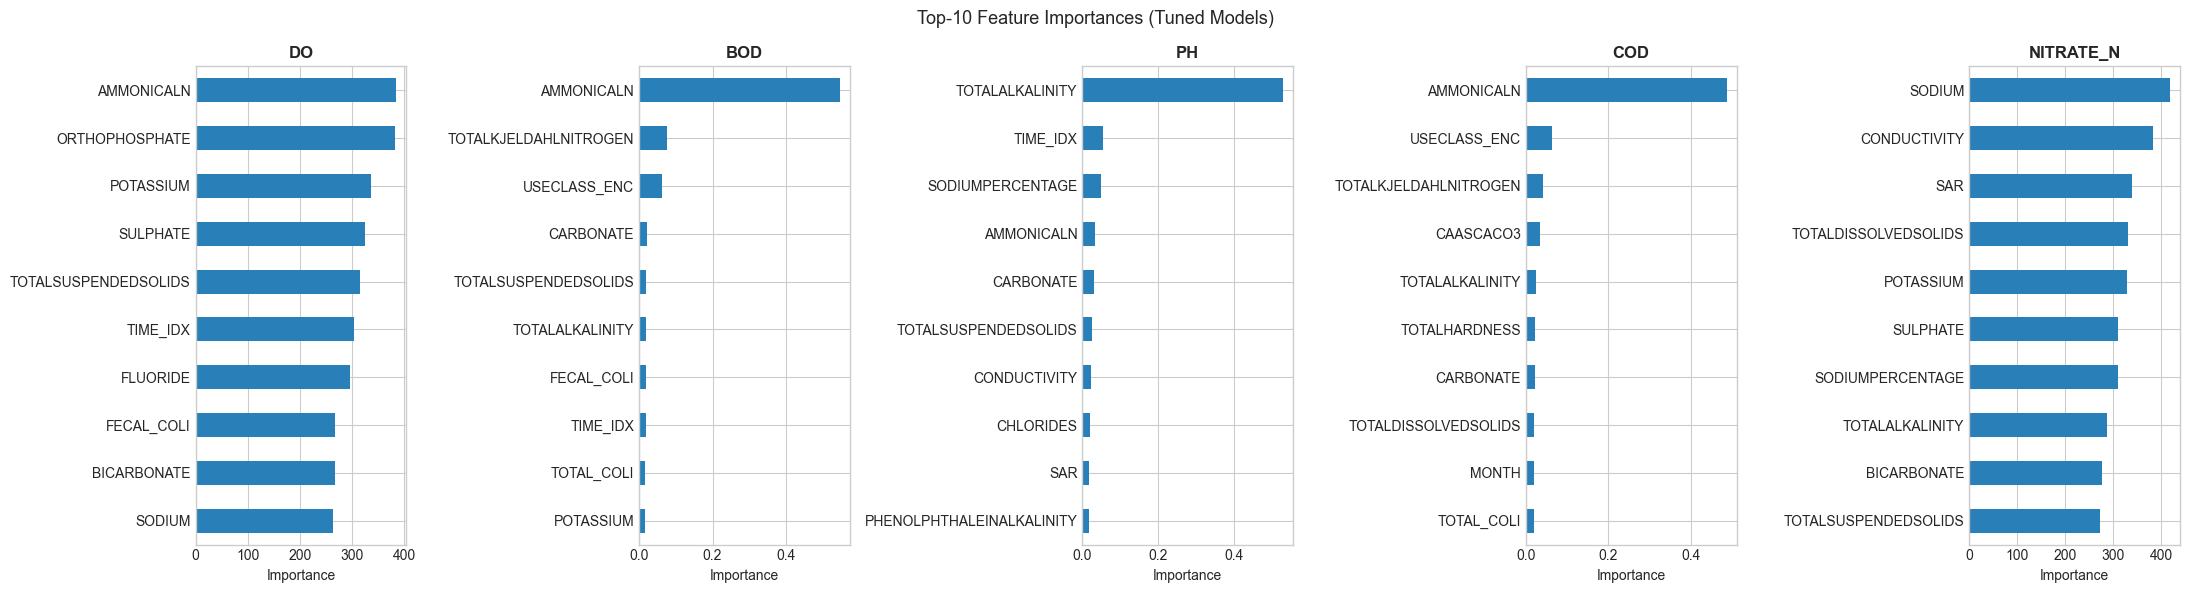

In [103]:
# Feature importances
fig, axes = plt.subplots(1, len(TARGETS), figsize=(22, 6))
for ax, t in zip(axes, TARGETS):
    if t not in tuned_results: continue
    est = tuned_results[t]['estimator']
    if hasattr(est, 'feature_importances_'):
        fi = pd.Series(est.feature_importances_, index=feat_avail).nlargest(10)
        fi[::-1].plot(kind='barh', ax=ax, color='#2980b9')
        ax.set_title(t, fontweight='bold'); ax.set_xlabel('Importance')
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center'); ax.set_title(t)
plt.suptitle('Top-10 Feature Importances (Tuned Models)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Neural Networks — FNN, 1D-CNN, LSTM

In [104]:
if not HAS_TF:
    print('⚠️  TensorFlow not installed. Run: pip install tensorflow')

In [105]:
if HAS_TF:
    def build_fnn(d, units=128, drop=0.3):
        m = keras.Sequential([
            layers.Input((d,)),
            layers.Dense(units, activation='relu'), layers.BatchNormalization(), layers.Dropout(drop),
            layers.Dense(units//2, activation='relu'), layers.BatchNormalization(), layers.Dropout(drop),
            layers.Dense(units//4, activation='relu'),
            layers.Dense(1)
        ], name='FNN')
        m.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return m

    def build_cnn1d(d, filters=64, drop=0.3):
        m = keras.Sequential([
            layers.Input((d, 1)),
            layers.Conv1D(filters, 3, activation='relu', padding='same'), layers.BatchNormalization(),
            layers.MaxPooling1D(2),
            layers.Conv1D(filters*2, 3, activation='relu', padding='same'), layers.BatchNormalization(),
            layers.GlobalAveragePooling1D(),
            layers.Dense(64, activation='relu'), layers.Dropout(drop),
            layers.Dense(1)
        ], name='CNN1D')
        m.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return m

    def build_lstm(d, units=64, drop=0.2):
        m = keras.Sequential([
            layers.Input((d, 1)),
            layers.LSTM(units, return_sequences=True, dropout=drop),
            layers.LSTM(units//2, dropout=drop),
            layers.Dense(32, activation='relu'),
            layers.Dense(1)
        ], name='LSTM')
        m.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return m

    ES = keras.callbacks.EarlyStopping('val_loss', patience=15, restore_best_weights=True)
    FIT_KW = dict(epochs=80, batch_size=32, validation_split=0.15, callbacks=[ES], verbose=0)
    print('✅ Neural net builders ready')

✅ Neural net builders ready


In [106]:
nn_results = {}

if HAS_TF:
    for target in TARGETS:
        if target not in df_clean.columns: continue
        y    = df_clean[target].values
        mask = ~np.isnan(y)
        Xm, ym = X[mask], y[mask]
        X_tr, X_te, y_tr, y_te = train_test_split(Xm, ym, test_size=0.2, random_state=42)
        sc = StandardScaler()
        Xtr = sc.fit_transform(X_tr)
        Xte = sc.transform(X_te)
        d   = Xtr.shape[1]

        print(f'\n{"="*50}\n  NN TARGET: {target}\n{"="*50}')
        nn_results[target] = {}

        # FNN
        print('  FNN...')
        fnn = build_fnn(d)
        fnn.fit(Xtr, y_tr, **FIT_KW)
        nn_results[target]['FNN'] = compute_metrics(y_te, fnn.predict(Xte, verbose=0).ravel(), 'FNN')
        print(f'  FNN  R²={nn_results[target]["FNN"]["R2"]}')

        # CNN1D
        print('  CNN1D...')
        Xtr3, Xte3 = Xtr.reshape(-1,d,1), Xte.reshape(-1,d,1)
        cnn = build_cnn1d(d)
        cnn.fit(Xtr3, y_tr, **FIT_KW)
        nn_results[target]['CNN1D'] = compute_metrics(y_te, cnn.predict(Xte3, verbose=0).ravel(), 'CNN1D')
        print(f'  CNN  R²={nn_results[target]["CNN1D"]["R2"]}')

        # LSTM
        print('  LSTM...')
        lstm = build_lstm(d)
        lstm.fit(Xtr3, y_tr, **FIT_KW)
        nn_results[target]['LSTM'] = compute_metrics(y_te, lstm.predict(Xte3, verbose=0).ravel(), 'LSTM')
        print(f'  LSTM R²={nn_results[target]["LSTM"]["R2"]}')

    print('\n✅ Neural nets done')
else:
    print('⚠️  Skipped (no TensorFlow)')


  NN TARGET: DO
  FNN...
  FNN  R²=0.784
  CNN1D...
  CNN  R²=-0.6359
  LSTM...
  LSTM R²=0.234

  NN TARGET: BOD
  FNN...
  FNN  R²=-0.5981
  CNN1D...
  CNN  R²=-0.4846
  LSTM...
  LSTM R²=-0.0804

  NN TARGET: PH
  FNN...
  FNN  R²=0.4162
  CNN1D...
  CNN  R²=0.4839
  LSTM...
  LSTM R²=-0.0861

  NN TARGET: COD
  FNN...
  FNN  R²=-2.1457
  CNN1D...
  CNN  R²=-2.0665
  LSTM...
  LSTM R²=-1.9108

  NN TARGET: NITRATE_N
  FNN...
  FNN  R²=-0.2731
  CNN1D...
  CNN  R²=-0.5231
  LSTM...
  LSTM R²=0.2522

✅ Neural nets done


---
## 7. Comprehensive Comparison

In [107]:
final_summary = []
for target in TARGETS:
    if target not in all_results: continue
    for _, row in all_results[target].iterrows():
        final_summary.append({'Target': target, 'Category': 'Classical',
                               'Model': row['Model'], 'R2': row['R2'],
                               'RMSE': row['RMSE'], 'MAE': row['MAE']})
    if target in tuned_results:
        m = tuned_results[target]['metrics']
        final_summary.append({'Target': target, 'Category': 'Tuned',
                               'Model': m['Model'], 'R2': m['R2'],
                               'RMSE': m['RMSE'], 'MAE': m['MAE']})
    if target in nn_results:
        for nn_name, nn_m in nn_results[target].items():
            final_summary.append({'Target': target, 'Category': 'NeuralNet',
                                   'Model': nn_name, 'R2': nn_m['R2'],
                                   'RMSE': nn_m['RMSE'], 'MAE': nn_m['MAE']})

df_final = pd.DataFrame(final_summary)
df_final.to_csv('all_model_results.csv', index=False)
print(f'Saved all_model_results.csv ({len(df_final)} rows)')

Saved all_model_results.csv (85 rows)


In [108]:
# Best R² per target per category
pivot = df_final.groupby(['Target','Category'])['R2'].max().unstack('Category').round(4)
print('\n=== Best R² per Target per Category ===')
display(pivot)


=== Best R² per Target per Category ===


Category,Classical,NeuralNet,Tuned
Target,,,
BOD,0.7411,-0.0804,0.7482
COD,0.7592,-1.9108,0.7577
DO,0.8367,0.7840,0.8322
NITRATE_N,0.7921,0.2522,0.7946
PH,0.7109,0.4839,0.7109


In [109]:
# # Master bar chart
# from matplotlib.patches import Patch
# cat_colors = {'Classical': '#3498db', 'Tuned': '#e67e22', 'NeuralNet': '#9b59b6'}
# n = len(TARGETS)
# fig, axes = plt.subplots(n, 1, figsize=(14, 5*n))
# if n == 1: axes = [axes]
# for ax, target in zip(axes, TARGETS):
#     sub = df_final[df_final['Target'] == target].sort_values('R2', ascending=False)
#     ax.barh(sub['Model'], sub['R2'],
#             color=[cat_colors.get(c,'gray') for c in sub['Category']],
#             edgecolor='white', lw=0.5)
#     ax.set_title(f'Target: {target}', fontweight='bold')
#     ax.set_xlabel('R²'); ax.axvline(0,'k',lw=0.5); ax.invert_yaxis()
#     ax.legend(handles=[Patch(facecolor=v, label=k) for k,v in cat_colors.items()],
#               loc='lower right', fontsize=8)
# plt.suptitle('All Models — R² Comparison', fontsize=15, y=1.001)
# plt.tight_layout()
# plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

---
## 8. Temporal Predictions

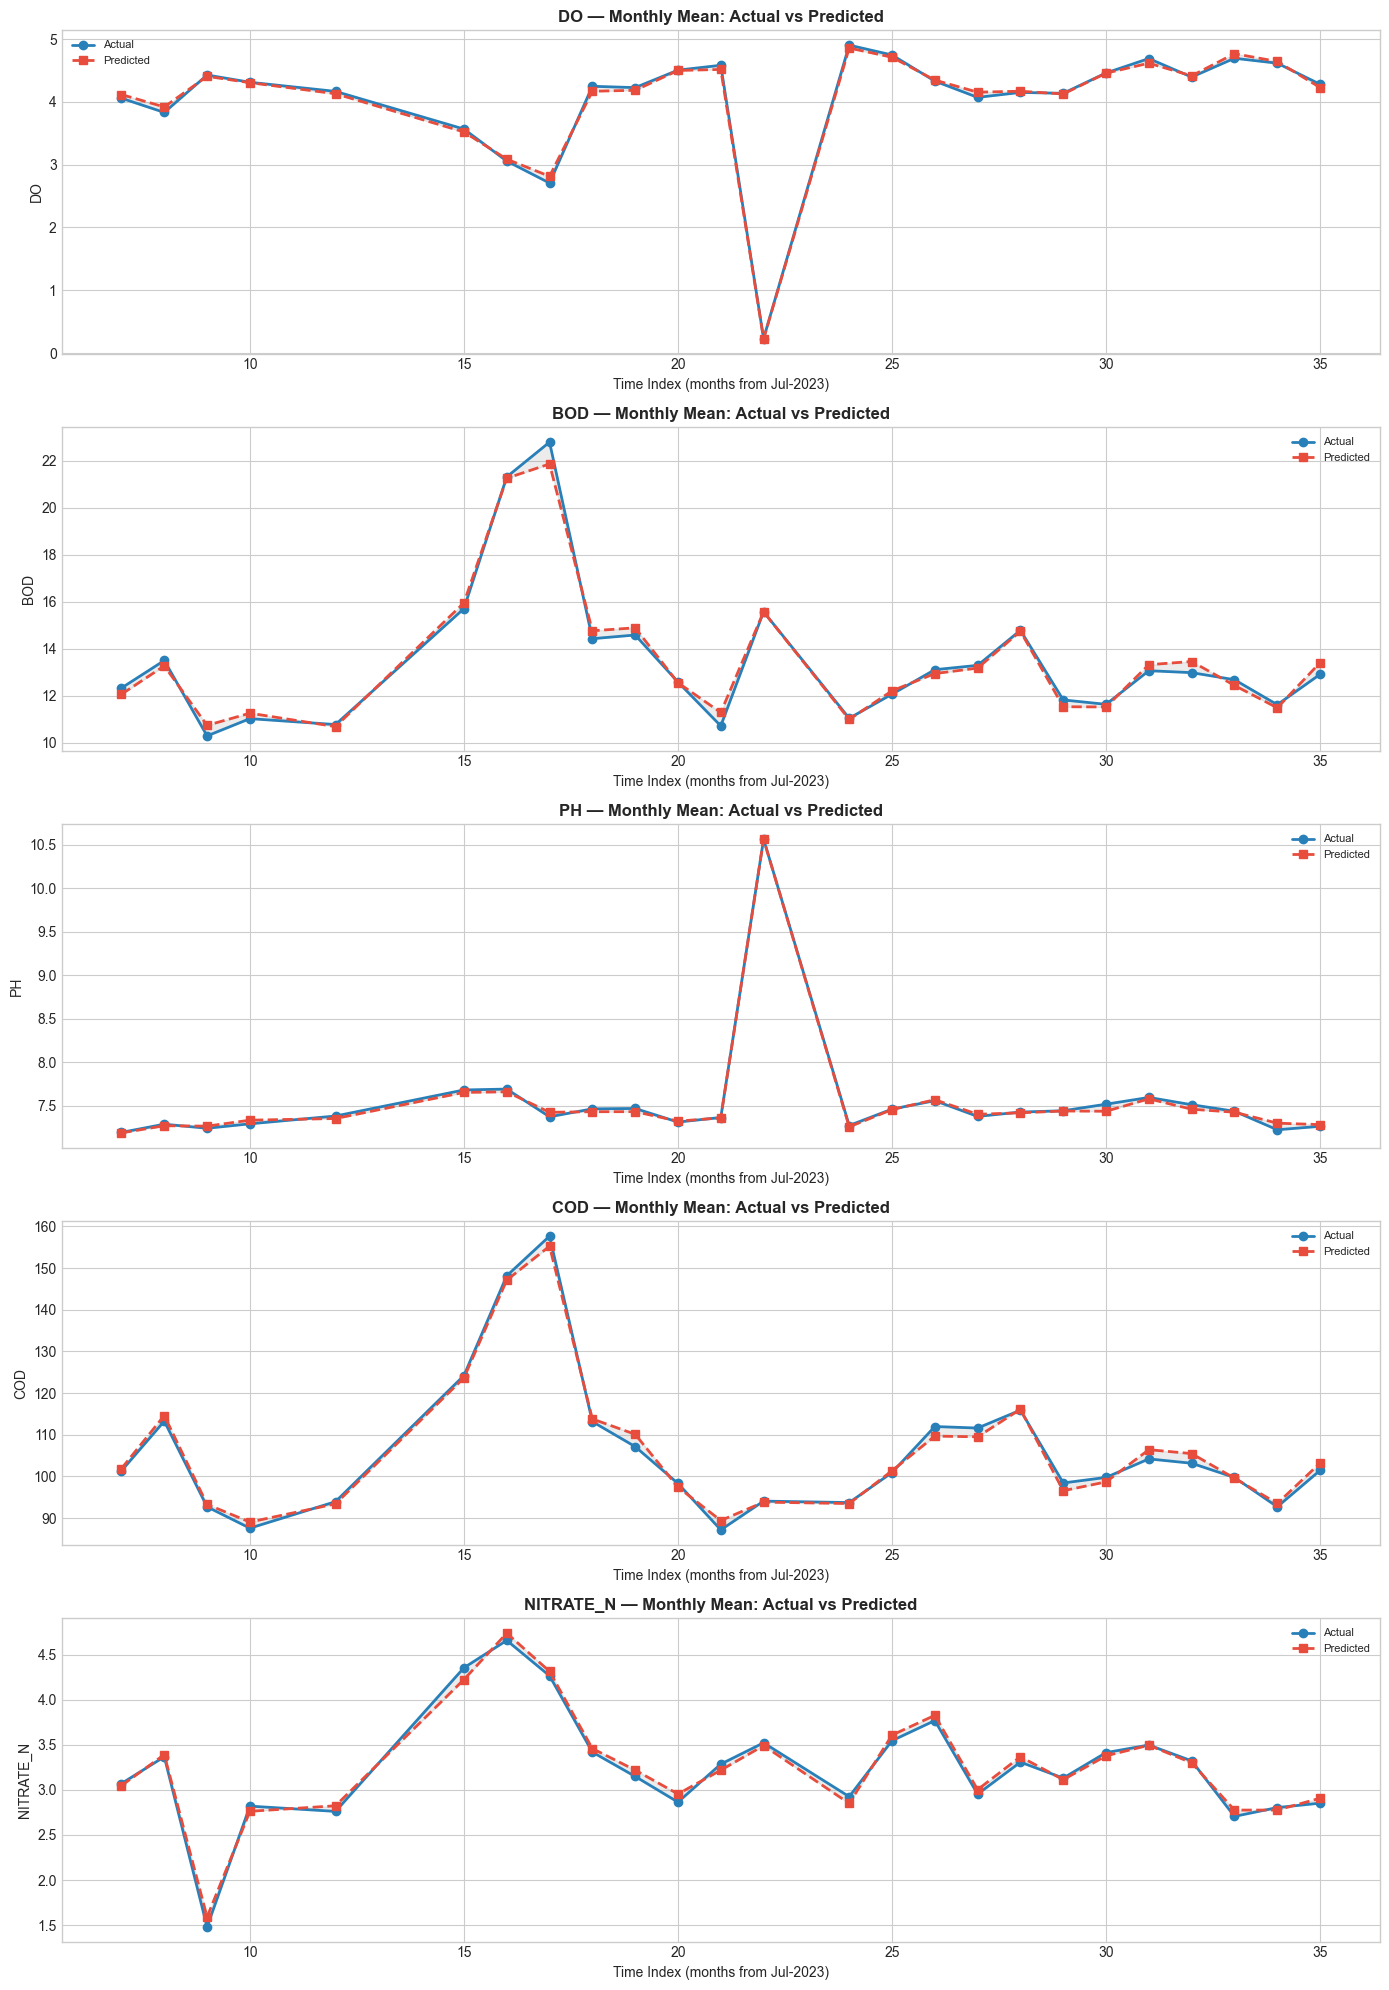

In [110]:
df_temp = df_clean.copy()

for target in TARGETS:
    if target not in tuned_results: continue
    tr = tuned_results[target]
    feat_vals = df_temp[feat_avail].values
    if tr['model_name'] in SCALE_MODELS:
        feat_vals = tr['scaler'].transform(feat_vals)
    df_temp[f'{target}_PRED'] = tr['estimator'].predict(feat_vals)

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(14, 4*len(TARGETS)))
if len(TARGETS) == 1: axes = [axes]
for ax, target in zip(axes, TARGETS):
    if f'{target}_PRED' not in df_temp.columns: continue
    grp = df_temp.groupby('TIME_IDX')[[target, f'{target}_PRED']].mean().sort_index()
    ax.plot(grp.index, grp[target], 'o-', label='Actual', color='#2980b9', lw=2)
    ax.plot(grp.index, grp[f'{target}_PRED'], 's--', label='Predicted', color='#e74c3c', lw=2)
    ax.fill_between(grp.index, grp[target], grp[f'{target}_PRED'],
                    alpha=0.15, color='gray')
    ax.set_title(f'{target} — Monthly Mean: Actual vs Predicted', fontweight='bold')
    ax.set_xlabel('Time Index (months from Jul-2023)'); ax.set_ylabel(target)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('temporal_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Scatter Plots: Actual vs Predicted

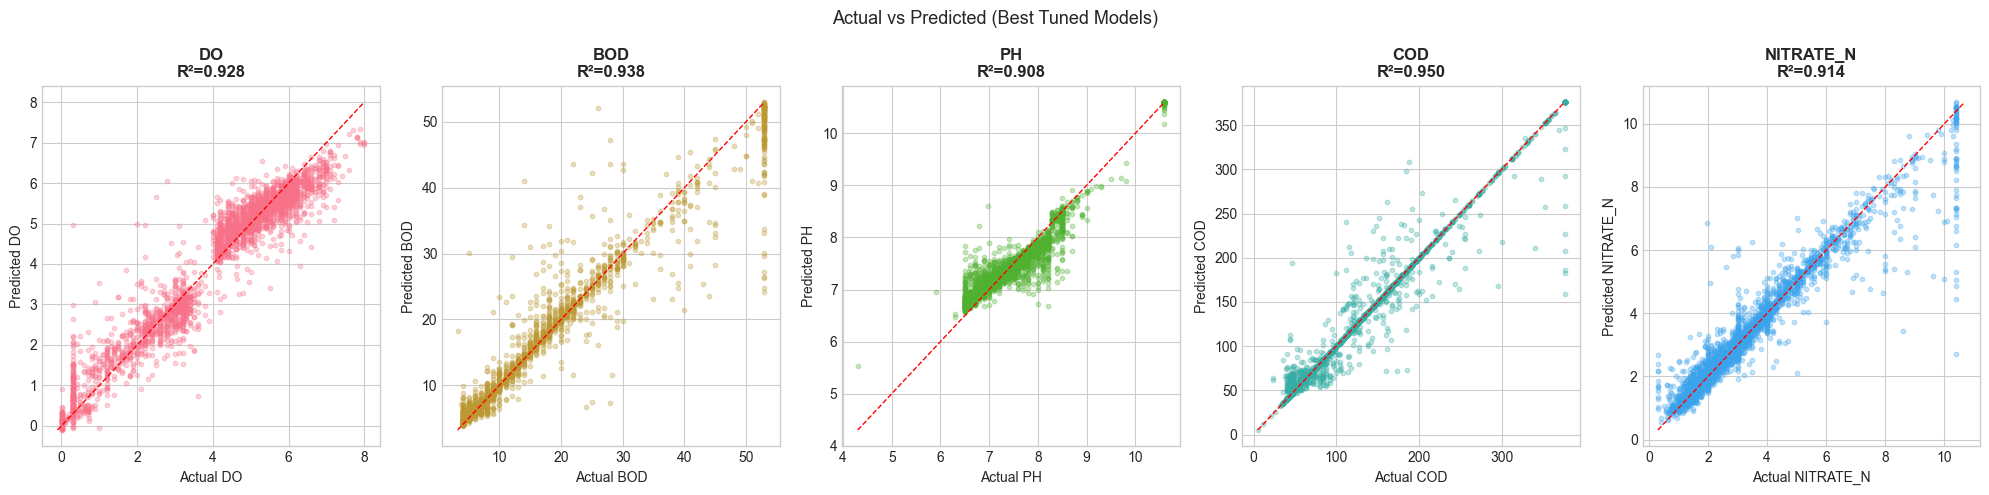

In [111]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(20, 5))
if len(TARGETS) == 1: axes = [axes]
for ax, target in zip(axes, TARGETS):
    if target not in df_temp.columns or f'{target}_PRED' not in df_temp.columns: continue
    act = df_temp[target].values
    prd = df_temp[f'{target}_PRED'].values
    ok  = ~(np.isnan(act) | np.isnan(prd))
    act, prd = act[ok], prd[ok]
    ax.scatter(act, prd, alpha=0.3, s=10, color=f'C{TARGETS.index(target)}')
    lim = [min(act.min(), prd.min()), max(act.max(), prd.max())]
    ax.plot(lim, lim, 'r--', lw=1)
    ax.set_xlabel(f'Actual {target}'); ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'{target}\nR²={r2_score(act,prd):.3f}', fontweight='bold')
plt.suptitle('Actual vs Predicted (Best Tuned Models)', fontsize=13)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Export Results & Final Leaderboard

In [112]:
# Export predictions CSV
id_cols = [c for c in ['MONTH_YEAR','STN_CODE','NAMEOFMONITORINGLOCATION'] if c in df.columns]
pred_cols  = [f'{t}_PRED' for t in TARGETS if f'{t}_PRED' in df_temp.columns]
actual_cols = [t for t in TARGETS if t in df_temp.columns]
export_df = pd.concat([df[id_cols].reset_index(drop=True),
                        df_temp[actual_cols + pred_cols].reset_index(drop=True)], axis=1)
export_df.to_csv('predictions_output.csv', index=False)
print(f'✅ predictions_output.csv saved ({export_df.shape})')
export_df.head()

✅ predictions_output.csv saved ((2924, 13))


,MONTH_YEAR,STN_CODE,NAMEOFMONITORINGLOCATION,DO,BOD,PH,COD,NITRATE_N,DO_PRED,BOD_PRED,PH_PRED,COD_PRED,NITRATE_N_PRED
0,07/23,5574.0,DEVASANDRA LAKE,4.4,7.0,8.2,88.0,1.0,4.933515,6.907208,7.834278,88.0,1.422146
1,07/23,5574.0,HEBBAL LAKE,4.7,8.0,7.2,72.0,2.0,4.715933,8.006958,7.140731,72.0,1.830433
2,07/23,5574.0,JAKKUR LAKE,2.6,12.0,7.0,119.0,4.1,2.537618,12.776250,7.095650,119.0,3.859726
3,07/23,5574.0,NAGAVARA LAKE,4.9,8.0,7.0,71.0,2.0,4.828600,8.003250,7.079412,71.0,1.899776
4,07/23,5574.0,CHELEKERE LAKE,4.8,8.0,7.1,70.0,0.3,4.870304,8.044083,7.120159,70.0,1.694500


In [113]:
# ── Final leaderboard ──────────────────────────────────────────────────────
print('\n' + '='*70)
print('  FINAL LEADERBOARD — Best Model per Target')
print('='*70)
for target in TARGETS:
    if target not in all_results: continue
    sub = df_final[df_final['Target'] == target].sort_values('R2', ascending=False)
    if len(sub) == 0: continue
    row = sub.iloc[0]
    print(f'  {target:<15} → {row["Model"]:<30}  R²={row["R2"]:.4f}  RMSE={row["RMSE"]:.4f}')
print('='*70)


  FINAL LEADERBOARD — Best Model per Target
  DO              → LightGBM                        R²=0.8367  RMSE=0.8002
  BOD             → ExtraTrees_Tuned                R²=0.7482  RMSE=6.2757
  PH              → RandomForest                    R²=0.7109  RMSE=0.4513
  COD             → ExtraTrees                      R²=0.7592  RMSE=34.4108
  NITRATE_N       → LightGBM_Tuned                  R²=0.7946  RMSE=0.9231
